In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

from numpy.random import seed
from tensorflow.random import set_seed
seed_value = 1234578790
seed(seed_value)
set_seed(seed_value)

Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

num_classes = 10
size = x_train.shape[1]

print('Train set:   ', len(y_train), 'samples')
print('Test set:    ', len(y_test), 'samples')
print('Sample dims: ', x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train set:    60000 samples
Test set:     10000 samples
Sample dims:  (60000, 28, 28)


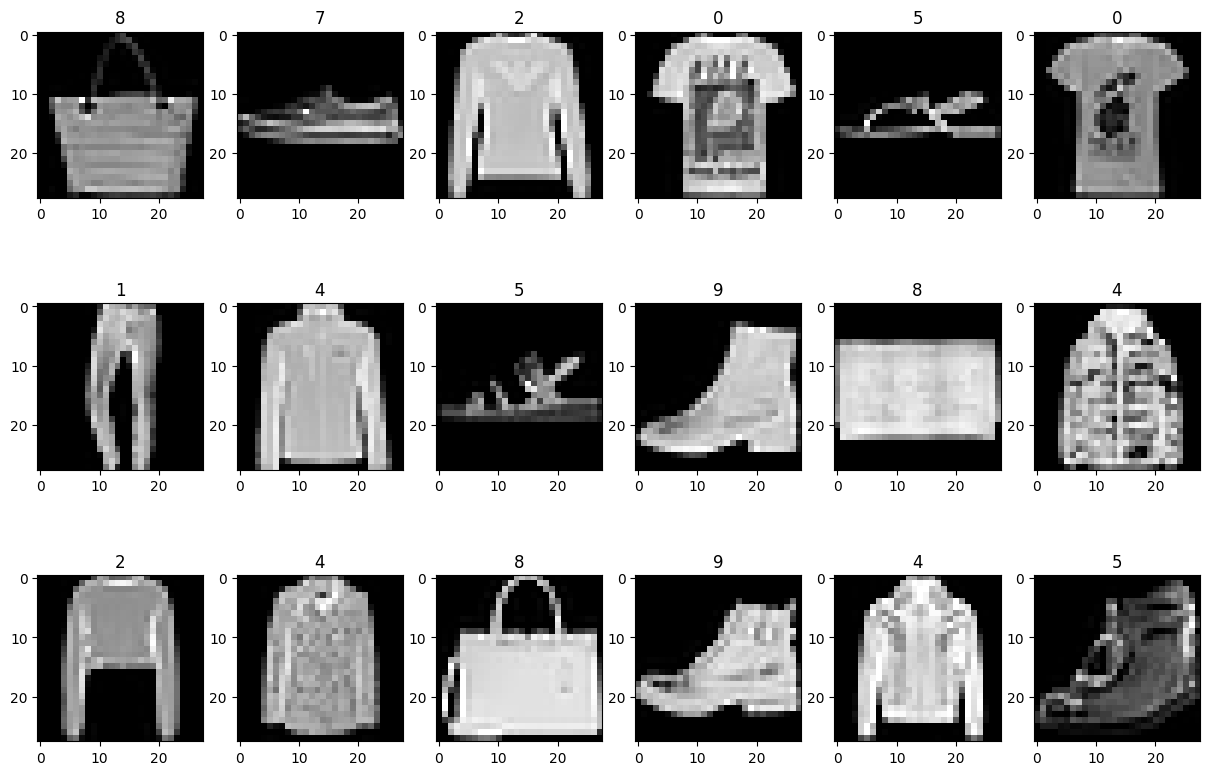

In [3]:
cnt = 1
for r in range(3):
    for c in range(6):
        idx = np.random.randint(len(x_train))
        plt.subplot(3,6,cnt)
        plt.imshow(x_train[idx, ...], cmap='gray')
        plt.title(y_train[idx])
        cnt = cnt + 1

Building the Classifier


In [4]:
x_train = x_train/255
x_test = x_test/255

In [5]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = Flatten()(net)
net = Dense(128)(net)
outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,002 (12.26 MB)

 Trainable params: 3,213,002 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
epochs = 50
batch_size = 64

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 72s 75ms/step - accuracy: 0.8660 - loss: 0.3861 - val_accuracy: 0.8843 - val_loss: 0.3219
Epoch 2/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9067 - loss: 0.2599 - val_accuracy: 0.8923 - val_loss: 0.3009
Epoch 3/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.9215 - loss: 0.2190 - val_accuracy: 0.8937 - val_loss: 0.3040
Epoch 4/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.9326 - loss: 0.1900 - val_accuracy: 0.8962 - val_loss: 0.3118
Epoch 5/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9413 - loss: 0.1658 - val_accuracy: 0.8930 - val_loss: 0.3314
Epoch 6/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.9481 - loss: 0.1476 - val_accuracy: 0.8954 - val_loss: 0.3553
Epoch 7/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 69ms/step - accuracy: 0.9546 - loss: 0.1302 - val_accuracy: 0.8929 - val_loss: 0.3784
Epoch 8/50
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.9594 - loss: 0.1176 - 

Train Acc      0.9918666481971741
Validation Acc 0.8761000037193298


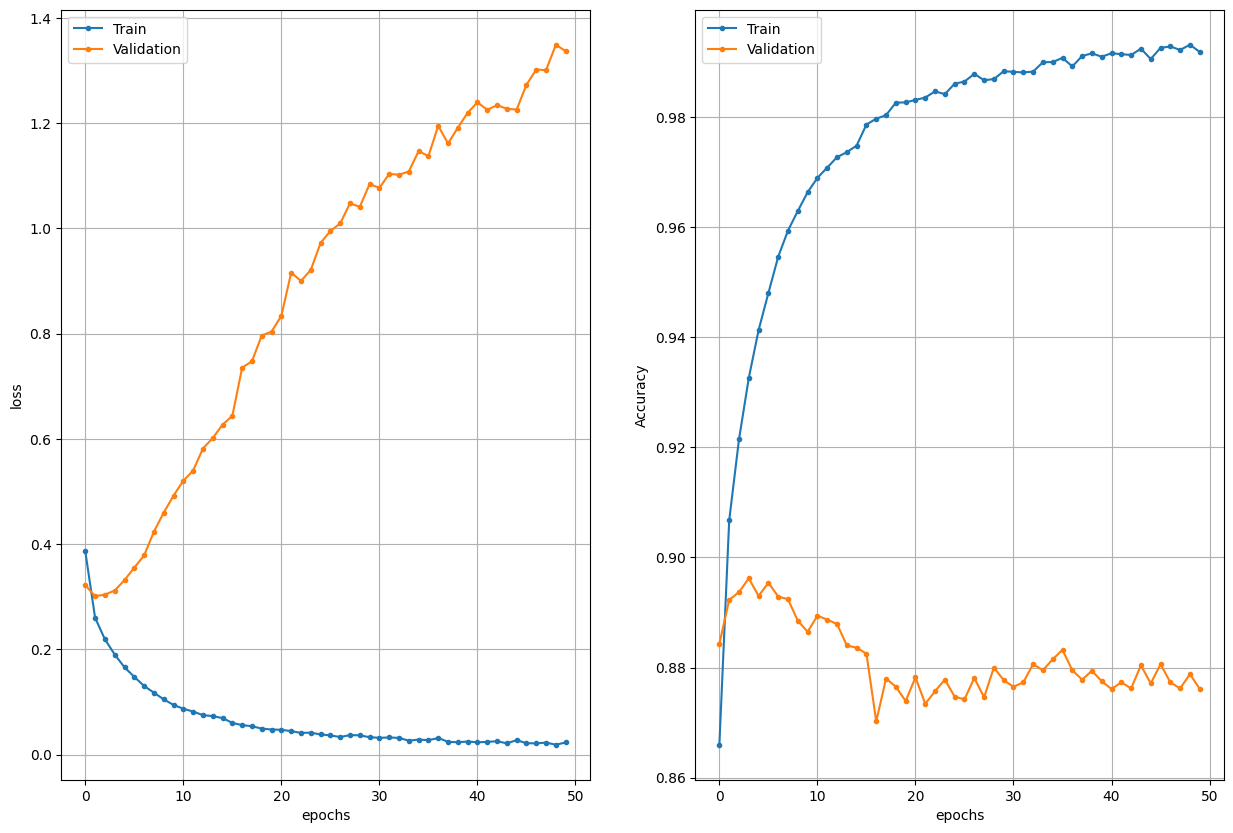

In [7]:
def plot_history(history):
    h = history.history
    epochs = range(len(h['loss']))

    plt.subplot(121), plt.plot(epochs, h['loss'], '.-', epochs, h['val_loss'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('loss')
    plt.legend(['Train', 'Validation'])
    plt.subplot(122), plt.plot(epochs, h['accuracy'], '.-',
                               epochs, h['val_accuracy'], '.-')
    plt.grid(True), plt.xlabel('epochs'), plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    print('Train Acc     ', h['accuracy'][-1])
    print('Validation Acc', h['val_accuracy'][-1])

plot_history(history)

Combat the Overfitting

In [8]:
inputs = Input(shape=(28, 28, 1))
net = Conv2D(32, kernel_size=(3, 3), activation="relu", padding='same')(inputs)
net = BatchNormalization()(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Conv2D(64, kernel_size=(3, 3), activation="relu", padding='same')(net)
net = BatchNormalization()(net)
net = MaxPooling2D(pool_size=(2, 2))(net)
net = Flatten()(net)
net = Dense(128, activation="relu")(net)
net = Dropout(0.5)(net)

outputs = Dense(10, activation="softmax")(net)

model = Model(inputs, outputs)

In [9]:
epochs = 50
batch_size = 64

model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2, verbose=1)

Epoch 1/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.8015 - loss: 0.5620 - val_accuracy: 0.8869 - val_loss: 0.3115
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 108ms/step - accuracy: 0.8661 - loss: 0.3742 - val_accuracy: 0.8936 - val_loss: 0.2890
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.8841 - loss: 0.3195 - val_accuracy: 0.9052 - val_loss: 0.2628
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.8958 - loss: 0.2853 - val_accuracy: 0.9016 - val_loss: 0.2685
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.9048 - loss: 0.2600 - val_accuracy: 0.9142 - val_loss: 0.2503
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.9119 - loss: 0.2412 - val_accuracy: 0.9164 - val_loss: 0.2363
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.9162 - loss: 0.2230 - val_accuracy: 0.9136 - val_loss: 0.2437
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 108ms/step - accuracy: 0.9227 - loss: 0

Train Acc      0.9783541560173035
Validation Acc 0.9265000224113464
Test accuracy: 0.9196000099182129


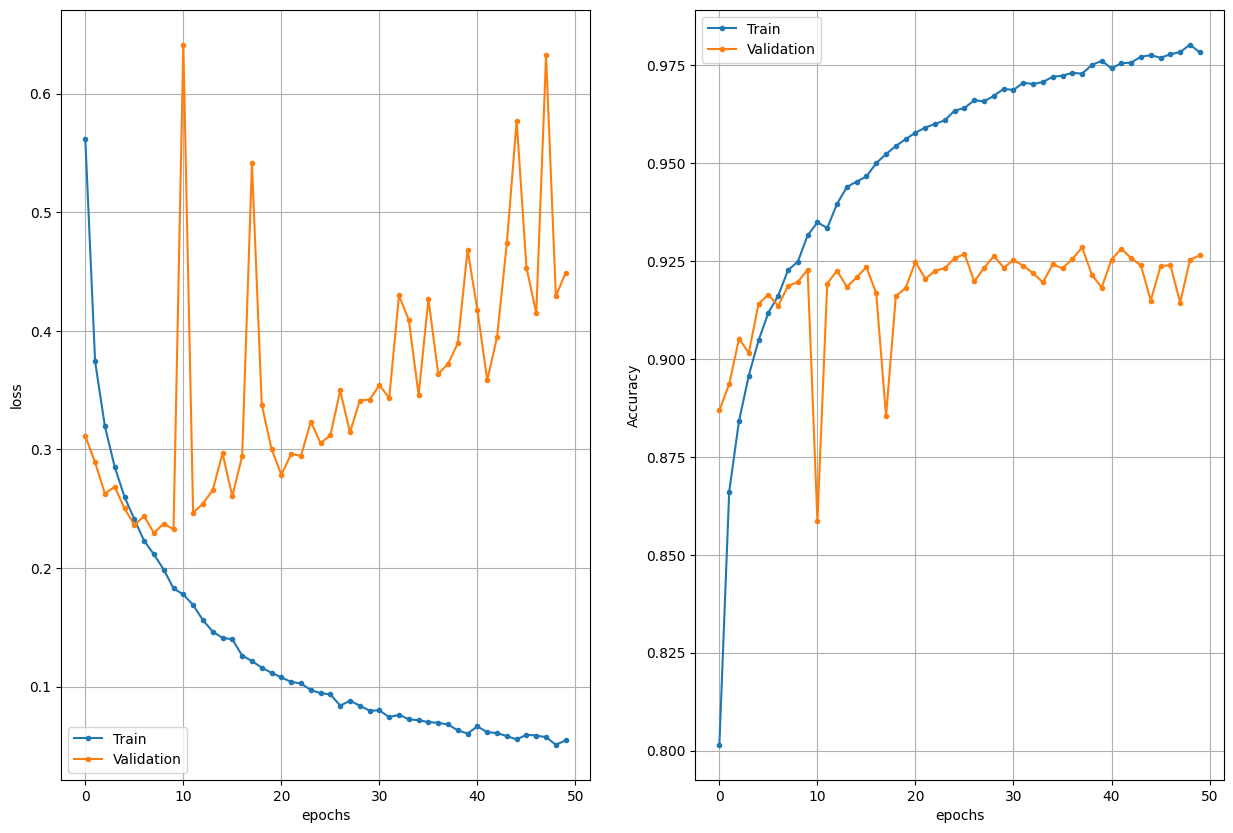

In [10]:
plot_history(history)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Добавил Dropout (0.5), BatchNormalization, MaxPooling и сделал сеть глубже. Настроек которые не сработали, у меня, не было.